In [19]:
# IMPORT LIBRARIES

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
# LOAD RCB DATA

In [22]:
rcb_matches = pd.read_csv(r"H:\Project1\rcb_clean.csv")
My_Team = 'Royal Challengers Bengaluru'

In [23]:
# QUICK SANITY CHECK

In [24]:
print(f"Rows: {rcb_matches.shape[0]}, Columns: {rcb_matches.shape[1]}")
rcb_matches.head(3)

Rows: 255, Columns: 21


,Unnamed: 0,id,season,city,date,match_type,player_of_match,venue,team1,team2,...,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,...,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,...,bat,Royal Challengers Bengaluru,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
2,10,335992,2007/08,Bangalore,2008-04-26,League,SR Watson,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Rajasthan Royals,...,field,Rajasthan Royals,wickets,7.0,136.0,20.0,N,NaN,MR Benson,IL Howell


In [25]:
# GROUP BY SEASON & CALCULATE WIN%

In [26]:
wins = rcb_matches[rcb_matches['winner']==My_Team].groupby('season').count()
matches = rcb_matches.groupby('season')['team2'].count()
season_summary = pd.DataFrame({
    'wins':wins['winner'],
    'Total_matches':matches
})
season_summary['win%'] = (season_summary['wins']/season_summary['Total_matches'] * 100).round(1)

#Display the table
season_summary

,wins,Total_matches,win%
season,,,
2007/08,4,14,28.6
2009,9,16,56.2
2009/10,8,16,50.0
2011,10,16,62.5
2012,8,15,53.3
2013,9,16,56.2
2014,5,14,35.7
2015,8,16,50.0
2016,9,16,56.2


In [27]:
# FIND BEST & WORST SEASONS

In [29]:
best_season = season_summary['win%'].idxmax()
worst_season = season_summary['win%'].idxmin()

print(f" Best Season: {best_season} — {season_summary.loc[best_season, 'win%']}%")
print(f" Worst Season: {worst_season} — {season_summary.loc[worst_season, 'win%']}%")

 Best Season: 2011 — 62.5%
 Worst Season: 2017 — 23.1%


In [30]:
# BAR CHART: WIN% BY SEASON

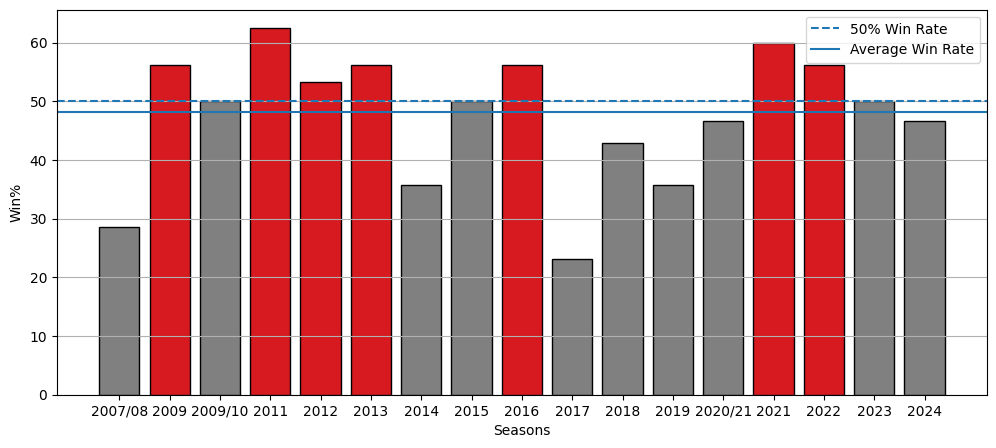

In [31]:
colors = ['#D71920' if pct>50 else '#808080' for pct in season_summary['win%']]
plt.figure(figsize=(12,5))
plt.bar(season_summary.index,season_summary['win%'],color=colors,edgecolor='black')
plt.grid(axis='y')
plt.axhline(y=50,linestyle='--',label='50% Win Rate')
plt.axhline(y=48.2,linestyle='-',label='Average Win Rate')
plt.xlabel("Seasons")
plt.ylabel("Win%")
plt.legend()
plt.show()

Day 2 Summary: Season-by-Season Win% Trend

Key Findings:
- Overall win percentage: 48.2% across 255 matches
- **Best season:** 2011 — 62.5% win rate
- **Worst season:** 2017 — 23.1% win rate
- **Seasons above 50%:** 7
- **Seasons below 50%:** 10

Observation:
RCB's performance has been inconsistent, with only a handful of seasons crossing the 50% win mark. Despite flashes of individual brilliance, the team has struggled to maintain a winning momentum across seasons.

Next:
Day 3 — Toss analysis: Does winning the toss actually help RCB win matches?